In [7]:
# 加载所需库
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


In [8]:
# 指定npz目录
base_dir = Path('custom_linear_plots')
npz_dir = base_dir / 'numpy_data'
print('npz_dir =', npz_dir)

if not npz_dir.exists():
    raise FileNotFoundError(f"目录不存在: {npz_dir}. 请先运行训练并启用保存功能。")

npz_files = sorted(npz_dir.glob('*.npz'))
print(f'found {len(npz_files)} files')
for f in npz_files[:5]:
    print(' -', f.name)


npz_dir = custom_linear_plots/numpy_data
found 145 files
 - layer_0.attention.output.dense_data.npz
 - layer_0.attention.self.key_data.npz
 - layer_0.attention.self.query_data.npz
 - layer_0.attention.self.value_data.npz
 - layer_0.intermediate.dense_data.npz


In [9]:
# 读取一个文件
if len(npz_files) == 0:
    raise RuntimeError('没有npz文件可读取')
else:
    print(f'共有 {len(npz_files)} 文件')

file_idx = 10
# npz_path = npz_files[file_idx]、
# data = np.load()
npz_path = 'custom_linear_plots/numpy_data/layer_0.attention.output.dense_data.npz'
print('reading:', npz_path)

data = np.load(npz_path, allow_pickle=True)
print('keys:', list(data.keys()))

# layer_index = int(data['layer_index']) if 'layer_index' in data else -1
inference_count = int(data['inference_count']) if 'inference_count' in data else -1
odd_cnt = int(data.get('odd_records_count', 0)) if 'odd_records_count' in data else 0
even_cnt = int(data.get('even_records_count', 0)) if 'even_records_count' in data else 0

# print('layer_index =', layer_index)
print('inference_count =', inference_count)
print('odd_records_count =', odd_cnt)
print('even_records_count =', even_cnt)


共有 145 文件
reading: custom_linear_plots/numpy_data/layer_0.attention.output.dense_data.npz
keys: ['layer_index', 'inference_count', 'odd_records_count', 'even_records_count', 'max_records', 'record_interval', 'odd_inputs', 'odd_outputs', 'odd_inputs_shape', 'odd_outputs_shape', 'even_inputs', 'even_outputs', 'even_inputs_shape', 'even_outputs_shape', 'stats']
inference_count = 318
odd_records_count = 4
even_records_count = 3


odd_inputs len = 4
odd_inputs_shape[:5] = [array([32, 45, 1024], dtype=object), array([4, 31, 1024], dtype=object), array([4, 36, 1024], dtype=object), array([4, 57, 1024], dtype=object)]
odd shape = (126976,)


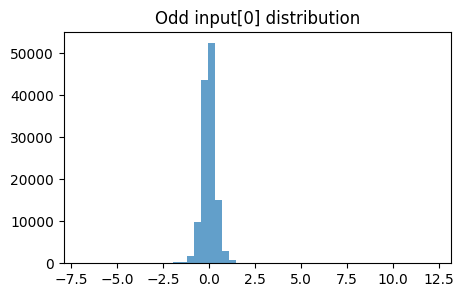

even_inputs len = 3
even_inputs_shape[:5] = [array([32, 45, 1024], dtype=object), array([4, 32, 1024], dtype=object), array([4, 47, 1024], dtype=object)]
even shape = (131072,)


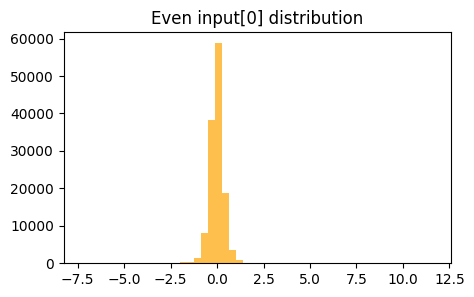

even_inputs len = 3
even_inputs_shape[:5] = [array([32, 45, 1024], dtype=object), array([4, 32, 1024], dtype=object), array([4, 47, 1024], dtype=object)]


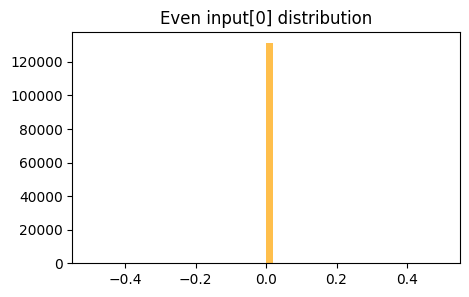

In [ ]:
# 访问存储的object数组，并简单查看形状

odd_inputs = data['odd_inputs'] if 'odd_inputs' in data else None
even_inputs = data['even_inputs'] if 'even_inputs' in data else None
odd_shapes = data['odd_inputs_shape'] if 'odd_inputs_shape' in data else None
even_shapes = data['even_inputs_shape'] if 'even_inputs_shape' in data else None
inference_time = 1

if odd_inputs is not None:
    # TODO: odd_inputs len != even_inputs len, which mean the CustomLinear is not correct
    print('odd_inputs len =', len(odd_inputs))
    if odd_shapes is not None:
        print('odd_inputs_shape[:5] =', list(odd_shapes[:5]))
    flat = odd_inputs[inference_time].ravel()
    print(f"odd shape = {flat.shape}")
    plt.figure(figsize=(5,3))
    plt.hist(flat, bins=50, alpha=0.7)
    plt.title('Odd input[0] distribution')
    plt.show()

if even_inputs is not None:
    print('even_inputs len =', len(even_inputs))
    if even_shapes is not None:
        print('even_inputs_shape[:5] =', list(even_shapes[:5]))
    flat = even_inputs[inference_time].ravel()
    print(f"even shape = {flat.shape}")
    plt.figure(figsize=(5,3))
    plt.hist(flat, bins=50, alpha=0.7, color='orange')
    plt.title('Even input[0] distribution')
    plt.show()

if even_inputs is not None and odd_inputs is not None:
    print('even_inputs len =', len(even_inputs))
    if even_shapes is not None:
        print('even_inputs_shape[:5] =', list(even_shapes[:5]))
    flat_even = even_inputs[inference_time].ravel()
    flat_odd = even_inputs[inference_time].ravel()
    flat_diff = flat_even - flat_odd
    plt.figure(figsize=(5,3))
    plt.hist(flat_diff, bins=50, alpha=0.7, color='orange')
    plt.title('Even input[0] distribution')
    plt.show()
